## Evaluacija i poređenje modela

U ovoj svesci evaluiramo i poredimo tri varijante Mini-CLIP modela, koje se razlikuju po image encoder-u.

Istrenirani modeli se nalaze na sledećem linku: https://drive.google.com/drive/u/0/folders/1k_PvqrXmhrLr_RMuwzBttYqbs3OQkYUL

Evaluacija se radi na test skupu -  slikama koje model nije video nikad pre.

In [1]:
import os
import re
import json
import ast
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from PIL import Image

from torch.utils.data import Dataset, DataLoader
from image_encoder import (
    ResNet18Encoder,
    ResNet18EncoderPretrained,
    ResNet18EncoderFineTuned
)

from text_encoder import MiniTextTransformer

### Podešavanje i učitavanje podataka

Test skup učitavamo iz `data/processed/test.csv`.
`test.csv` već sadrži pripremljene `input_ids` i `attention_mask`.
Posle učitavanja iz csv fajla te kolone su stringovi, pa je potrebno da ih parsiramo u Python liste.

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = "./data"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
IMAGES_DIR = os.path.join(DATA_DIR, "Images")
MODEL_DIR = "./models" # AKO SU MODELI SKINUTI NA NEKU DRUGU LOKACIJU, OVDE STAVITI PUTANJU

In [3]:
with open(os.path.join(PROCESSED_DIR, "vocab.json"), encoding="utf-8") as f:
    vocab_data = json.load(f)

VOCAB_SIZE = len(vocab_data["token_to_id"])
MAX_LENGTH = vocab_data["max_length"]
PAD_ID = vocab_data["token_to_id"]["<PAD>"]

#test skup - vec preprocesiran u 01_data_setup:
test_df = pd.read_csv(os.path.join(PROCESSED_DIR, "test.csv")).reset_index(drop=True)

In [4]:
def parse_list(value):
    return json.loads(value.replace("'", '"'))

test_df["input_ids"] = test_df["input_ids"].apply(parse_list)
test_df["attention_mask"] = test_df["attention_mask"].apply(parse_list)

#mapiranje za Recall@K
unique_images = test_df["image"].unique()
n_images = len(unique_images)
n_captions = len(test_df)

In [5]:
n_images

810

In [6]:
n_captions

4050

In [7]:
test_df.head()

,image,caption,input_ids,attention_mask
0,1022454428_b6b660a67b.jpg,"a couple and an infant , being held by the mal...","[2, 60, 1615, 221, 216, 3420, 11, 627, 3189, 1...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,1022454428_b6b660a67b.jpg,a couple sit on the grass with a baby and stro...,"[2, 60, 1615, 6028, 4476, 6895, 2953, 7625, 60...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, ..."
2,1022454428_b6b660a67b.jpg,a couple with their newborn baby sitting under...,"[2, 60, 1615, 7625, 6897, 4354, 417, 6033, 723...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,1022454428_b6b660a67b.jpg,a man and woman care for an infant along the s...,"[2, 60, 3968, 221, 7636, 1111, 2672, 216, 3420...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,1022454428_b6b660a67b.jpg,couple with a baby sit outdoors next to their ...,"[2, 1615, 7625, 60, 417, 6028, 4541, 4361, 698...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, ..."


In [8]:
image_to_idx = {img: i for i, img in enumerate(unique_images)}
image_to_caption_idxs = [[] for _ in range(n_images)]
for caption_idx, row in test_df.iterrows():
    img_idx = image_to_idx[row["image"]]
    image_to_caption_idxs[img_idx].append(caption_idx)

In [9]:
# Isti image transform kao u `01_data_setup.ipynb`
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

## Učitavanje modela

In [18]:
EMB_DIM = 256
K_VALS = [1, 5, 10]

#TODO dodati i ostale modele nakon treninga
# napomena: za razliciti batch size loss nije uporediv
MODEL_CONFIG = [
    { 
        "enc_class": ResNet18EncoderPretrained,
        "checkpoint": os.path.join(MODEL_DIR, "pretrained_32bs_30e.pt"),
        "name": "pretrained"
    },
    { 
        "enc_class": ResNet18EncoderFineTuned,
        "checkpoint": os.path.join(MODEL_DIR, "fine_tuned_32bs_30e.pt"),
        "name": "fine-tuned"
    }
]

In [10]:
#loss iz 04
def clip_contrastive_loss(image_embeddings, text_embeddings, temperature=0.07):
    logits = (
        image_embeddings @ text_embeddings.T
    ) / temperature

    labels = torch.arange(logits.size(0), device=logits.device)

    image_to_text_loss = F.cross_entropy(logits, labels)

    text_to_image_loss = F.cross_entropy(logits.T, labels)

    loss = (image_to_text_loss + text_to_image_loss) / 2

    return loss

def build_and_load_model(config):
    image_encoder =  config["enc_class"](emb_dim=EMB_DIM).to(DEVICE)
    text_encoder = MiniTextTransformer(
        vocab_size=VOCAB_SIZE, 
        max_length=MAX_LENGTH, 
        padding_idx=PAD_ID, 
        output_dim=EMB_DIM).to(DEVICE)

    checkpoint = torch.load(config["checkpoint"], map_location=DEVICE)
    image_encoder.load_state_dict(checkpoint["image_encoder_state_dict"])
    text_encoder.load_state_dict(checkpoint["text_encoder_state_dict"])

    return image_encoder, text_encoder, checkpoint
    

In [11]:
@torch.no_grad()
def encode_all_images(image_encoder, batch_size=32):
    image_encoder.eval()
    all_emb = []
    for start in range(0, n_images, batch_size):
        names = unique_images[start:start+batch_size] 
        batch = torch.stack([
                image_transform(Image.open(os.path.join(IMAGES_DIR, n)).convert("RGB")) for n in names
        ]).to(DEVICE)
        all_emb.append(image_encoder(batch).cpu())
    return torch.cat(all_emb, dim=0)

In [12]:
@torch.no_grad()
def encode_all_captions(text_encoder, batch_size=32):
    text_encoder.eval()
    all_emb = []
    for start in range(0, n_captions, batch_size):
        chunk = test_df.iloc[start:start+batch_size]
        input_ids = torch.tensor(chunk["input_ids"].tolist(), dtype=torch.long).to(DEVICE)
        attention_mask = torch.tensor(chunk["attention_mask"].tolist(), dtype=torch.long).to(DEVICE)
        all_emb.append(text_encoder(input_ids, attention_mask).cpu())
    return torch.cat(all_emb, dim=0)

## Metrike
Pošto je cilj projekta pretraga slika na osnovu tekstualnog opisa (korisnik unosi tekst, model vraća odgovarajuću sliku), evaluacija se fokusira isključivo na **text -> image** smer.

Za svaki model računamo Recall@1, Recall@5 i Recall@10:
- **text -> image**: da li se tačna slika nalazi među top-K najsličnijih slika za dati opis.

Napomena: model je treniran simetričnim contrastive loss-om (oba smera istovremeno), pošto to doprinosi kvalitetu zajedničkog embedding prostora, ali se u evaluaciji prati samo metrika relevantna za ciljnu primenu.

In [13]:
def recall_text_to_image(image_emb, text_emb, k):
    sim = image_emb @ text_emb.T
    hits = []
    for caption_idx, (_, row) in enumerate(test_df.iterrows()):
        img_idx = image_to_idx[row["image"]]
        hits.append(img_idx in sim[:, caption_idx].topk(k).indices.tolist())

    return float(np.mean(hits))

In [14]:
class TestDataset(Dataset):
    def __len__(self):
        return len(test_df)

    def __getitem__(self, idx):
        row = test_df.iloc[idx]
        img = image_transform(Image.open(os.path.join(IMAGES_DIR, row["image"])).convert("RGB"))
        return (
            img, 
            torch.tensor(row["input_ids"], dtype=torch.long), 
            torch.tensor(row["attention_mask"], dtype=torch.long)
        )
                              

# TODO proveriti ovo dobro
@torch.no_grad()
def compute_test_loss(image_encoder, text_encoder, batch_size=32):
    loader = DataLoader(TestDataset(), batch_size=batch_size, shuffle=False)
    image_encoder.eval()
    text_encoder.eval()

    total = 0.0
    for images, input_ids, attention_mask in loader:
        images = images.to(DEVICE)
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)

        img_emb = image_encoder(images)
        txt_emb = text_encoder(input_ids, attention_mask)
        total += clip_contrastive_loss(img_emb, txt_emb).item()

    return total/len(loader)
    

In [15]:
def evaluate_model(config):
    image_encoder, text_encoder, checkpoint = build_and_load_model(config)
    img_emb = encode_all_images(image_encoder)
    txt_emb = encode_all_captions(text_encoder)

    result = {
        "model": config["name"],
        "epoch": checkpoint.get("epoch", -1),
        "val_loss": float(checkpoint.get("val_loss", float("nan"))),
        "test_loss": compute_test_loss(image_encoder, text_encoder)
    }

    for k in K_VALS:
        result[f"text2image_R@{k}"] = recall_text_to_image(img_emb, txt_emb, k)

    return result
        
    

## Evaluacija svih modela

Za svaki checkpoint učitavamo modele i računamo metrike na test skupu

TODO pokrenuti naredne celije na kraju

In [117]:
results = []
for config in MODEL_CONFIG:
    print(f" evaluating model {config['name']}")
    res = evaluate_model(config)
    results.append(res)

results_df = pd.DataFrame(results)
results_df.round(4)

 evaluating model pretrained
 evaluating model fine-tuned
 evaluating model from scratch


,model,epoch,val_loss,test_loss,image2text_R@1,text2image_R@1,image2text_R@5,text2image_R@5,image2text_R@10,text2image_R@10
0,pretrained,10,0.7480,1.7135,0.1099,0.0832,0.2926,0.2570,0.4383,0.3765
1,fine-tuned,10,1.6786,1.7943,0.1420,0.1143,0.3506,0.3069,0.4877,0.4341
2,from scratch,10,1.5008,1.8638,0.0173,0.0183,0.0765,0.0817,0.1185,0.1356


### Nova evaluacija modela

U ovom delu evaluiraju se modeli trenirani sa batch size 32
i različitim brojem epoha, kako bi se uporedili pretrained i fine-tuned pristupi.

In [21]:
NEW_MODEL_CONFIG = [
    {
        "enc_class": ResNet18EncoderPretrained,
        "checkpoint": os.path.join(MODEL_DIR, "pretrained_32b_10e.pt"),
        "name": "pretrained - 10 epochs"
    },
    {
        "enc_class": ResNet18EncoderPretrained,
        "checkpoint": os.path.join(MODEL_DIR, "pretrained_32bs_30e.pt"),
        "name": "pretrained - 30 epochs"
    },
    # {
    #     "enc_class": ResNet18EncoderFineTuned,
    #     "checkpoint": os.path.join(MODEL_DIR, "fine_tuned_32bs_10e.pt"),
    #     "name": "fine-tuned - 10 epochs"
    # },
    {
        "enc_class": ResNet18EncoderFineTuned,
        "checkpoint": os.path.join(MODEL_DIR, "fine_tuned_32bs_30e.pt"),
        "name": "fine-tuned - 30 epochs"
    }
]

In [22]:
new_results = []

for config in NEW_MODEL_CONFIG:
    print(f"Evaluating model {config['name']}")

    result = evaluate_model(config)
    new_results.append(result)

new_results_df = pd.DataFrame(new_results)
new_results_df.round(4)

Evaluating model pretrained - 10 epochs
Evaluating model pretrained - 30 epochs
Evaluating model fine-tuned - 30 epochs


,model,epoch,val_loss,test_loss,text2image_R@1,text2image_R@5,text2image_R@10
0,pretrained - 10 epochs,10,1.6461,2.3384,0.1062,0.2973,0.4249
1,pretrained - 30 epochs,29,1.4552,2.2828,0.1215,0.3548,0.4805
2,fine-tuned - 30 epochs,22,1.6552,2.4356,0.1267,0.3368,0.4583


## Poređenje rezultata

### Pretrained vs fine-tuned pristup

Za direktno poređenje pretrained i fine-tuned pristupa posmatrani su modeli
trenirani sa istim batch size-om i tokom 30 epoha.

Fine-tuned model ostvaruje nešto veći Recall@1 (12.67% naspram 12.15%),
dok pretrained model ostvaruje bolje Recall@5 (35.48% naspram 33.68%)
i Recall@10 (48.05% naspram 45.83%).

Na osnovu ovih rezultata fine-tuning nije doveo do konzistentnog poboljšanja
retrieval performansi. Pretrained model daje bolje rezultate za veće vrednosti
K, dok fine-tuned model ima malu prednost samo za Recall@1.

### Uticaj broja epoha na pretrained model

Kod pretrained pristupa povećanje broja epoha sa 10 na 30 poboljšalo je sve
Recall metrike. Recall@1 je porastao sa 10.62% na 12.15%, Recall@5 sa
29.73% na 35.48%, a Recall@10 sa 42.49% na 48.05%.

Ovi rezultati pokazuju da je duži trening imao pozitivan efekat na pretrained
varijantu modela.

### Grafičko poređenje Recall metrika

Radi preglednijeg prikaza rezultata, prikazane su Recall@1, Recall@5 i
Recall@10 metrike za tri evaluirane varijante modela.

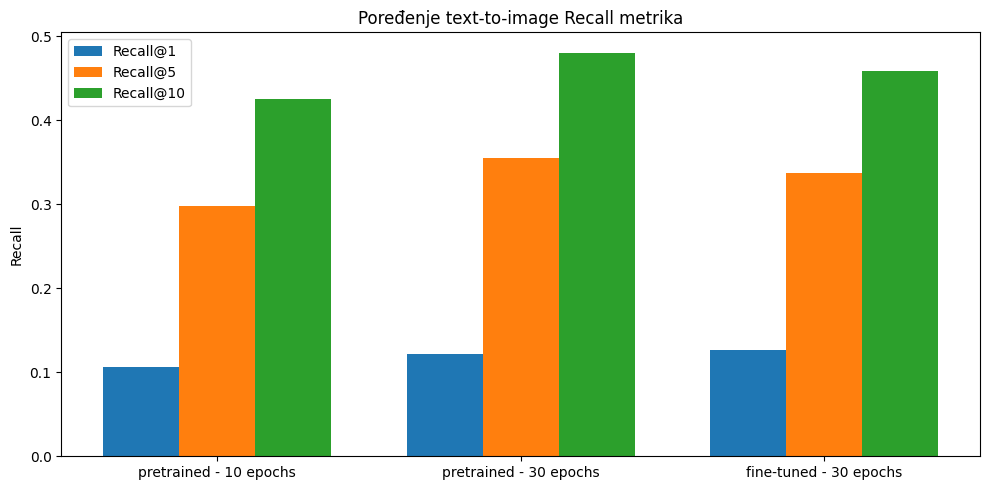

In [23]:
metrics = [
    "text2image_R@1",
    "text2image_R@5",
    "text2image_R@10"
]

metric_labels = ["Recall@1", "Recall@5", "Recall@10"]

x = np.arange(len(new_results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - 1) * width,
        new_results_df[metric],
        width,
        label=metric_labels[i]
    )

ax.set_xticks(x)
ax.set_xticklabels(new_results_df["model"])
ax.set_ylabel("Recall")
ax.set_title("Poređenje text-to-image Recall metrika")
ax.legend()

plt.tight_layout()
plt.show()

### Uticaj dužeg treninga na Recall

Kako bi se detaljnije prikazao efekat povećanja broja epoha,
prikazana je promena Recall metrika pretrained modela između
10. i 30. epohe.

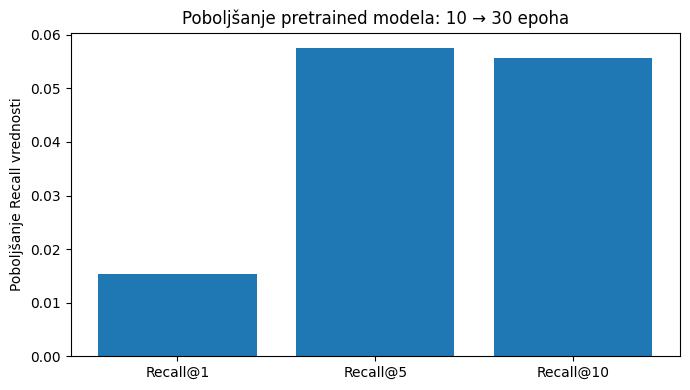

In [25]:
improvements = [
    0.1215 - 0.1062,
    0.3548 - 0.2973,
    0.4805 - 0.4249
]

labels = ["Recall@1", "Recall@5", "Recall@10"]

plt.figure(figsize=(7, 4))
plt.bar(labels, improvements)

plt.ylabel("Poboljšanje Recall vrednosti")
plt.title("Poboljšanje pretrained modela: 10 → 30 epoha")

plt.tight_layout()
plt.show()

Najveće poboljšanje primećuje se kod Recall@5 i Recall@10, dok je
povećanje Recall@1 znatno manje. Ovo ukazuje da je duži trening
pre svega poboljšao rangiranje relevantne slike među prvih nekoliko
rezultata, dok je uticaj na izbor slike na prvoj poziciji bio manji.